# 04 - MobileNetV2 Transfer Learning

This experiment uses MobileNetV2 pretrained on ImageNet. It carries forward the best baseline strategy from `03B`:

- on-the-fly augmentation during training
- mild targeted oversampling on the training dataframe
- no class weights

The goal is to test whether transfer learning improves over the best baseline CNN:

- best baseline CNN (`03B`) accuracy: about 0.7561
- best baseline CNN (`03B`) macro F1: about 0.7217


## 1. Project setup


In [ ]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "src").exists() else NOTEBOOK_DIR.parent

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError(f"Could not find src/ from current directory: {NOTEBOOK_DIR}")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


Project root: d:\UWE\3rd Year\2nd semester\advanced_ai\ai_system


## 2. Imports and configuration

MobileNetV2 pretrained weights may be downloaded the first time this notebook runs. If your environment has no internet, set `PRETRAINED_WEIGHTS = None`, but that removes the transfer-learning advantage.


In [ ]:
import json
from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay

from src.config import (
    CLASS_NAMES_PATH,
    CM_DIR,
    FIGURES_DIR,
    IMAGE_SIZE,
    MODELS_DIR,
    NUM_CLASSES,
    RANDOM_SEED,
    GROUPED_SPLITS_DIR,
)

# Use grouped source-image splits to avoid offline-augmentation leakage.
SPLITS_DIR = GROUPED_SPLITS_DIR
from src.data.augmentations import build_training_augmentation
from src.data.dataloaders import make_dataset_from_dataframe
from src.data.prepare_dataset import targeted_oversample_dataframe
from src.models.mobilenetv2_model import build_mobilenetv2_model
from src.train.evaluate import evaluate_model
from src.train.train import compile_model, train_model

tf.keras.utils.set_random_seed(RANDOM_SEED)

EXPERIMENT_NAME = "mobilenetv2_aug_oversampled"
TARGET_MIN_COUNT = 500
PRETRAINED_WEIGHTS = "imagenet"

HEAD_EPOCHS = 8
HEAD_LEARNING_RATE = 1e-3


EXPERIMENT_MODELS_DIR = MODELS_DIR / "experiments"
EXPERIMENT_MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
CM_DIR.mkdir(parents=True, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))
print("Experiment:", EXPERIMENT_NAME)
print("Input size:", IMAGE_SIZE)
print("Target minimum train count:", TARGET_MIN_COUNT)


TensorFlow: 2.21.0
GPUs: []
Experiment: mobilenetv2_aug_oversampled
Input size: (224, 224)
Target minimum train count: 500
Run fine tuning: False


## 3. Load split files and class names


In [ ]:
train_csv = SPLITS_DIR / "train.csv"
val_csv = SPLITS_DIR / "val.csv"
test_csv = SPLITS_DIR / "test.csv"

for path in [train_csv, val_csv, test_csv, CLASS_NAMES_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}. Run 01_eda.ipynb first.")

train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

with open(CLASS_NAMES_PATH, "r", encoding="utf-8") as f:
    class_names = json.load(f)

class_to_index = {name: idx for idx, name in enumerate(class_names)}

for split_df in [train_df, val_df, test_df]:
    if "class_index" not in split_df.columns:
        split_df["class_index"] = split_df["class_name"].map(class_to_index)

print("Original train/val/test:", len(train_df), len(val_df), len(test_df))
print("Classes:", len(class_names))
assert len(class_names) == NUM_CLASSES


Original train/val/test: 20493 4392 4392
Classes: 28


## 4. Mild targeted oversampling

Only training rows are oversampled. Validation and test remain untouched.


In [ ]:
original_counts = train_df["class_name"].value_counts().reindex(class_names)
train_oversampled_df = targeted_oversample_dataframe(
    train_df,
    target_min_count=TARGET_MIN_COUNT,
    class_column="class_name",
    random_state=RANDOM_SEED,
)

oversampled_counts = train_oversampled_df["class_name"].value_counts().reindex(class_names)
oversampling_summary = pd.DataFrame({
    "class_name": class_names,
    "original_train_count": original_counts.values,
    "oversampled_train_count": oversampled_counts.values,
})
oversampling_summary["added_rows"] = (
    oversampling_summary["oversampled_train_count"]
    - oversampling_summary["original_train_count"]
)
oversampling_summary["oversampled_ratio"] = (
    oversampling_summary["oversampled_train_count"]
    / oversampling_summary["original_train_count"]
).round(2)

display(oversampling_summary.sort_values("added_rows", ascending=False))
print("Original train rows:", len(train_df))
print("Oversampled train rows:", len(train_oversampled_df))
print("Added rows:", len(train_oversampled_df) - len(train_df))


,class_name,original_train_count,oversampled_train_count,added_rows,oversampled_ratio
11,Grape__Rotten,140,500,360,3.57
10,Grape__Healthy,140,500,360,3.57
13,Guava__Rotten,140,500,360,3.57
12,Guava__Healthy,140,500,360,3.57
15,Jujube__Rotten,140,500,360,3.57
14,Jujube__Healthy,140,500,360,3.57
20,Pomegranate__Healthy,140,500,360,3.57
21,Pomegranate__Rotten,140,500,360,3.57
7,Carrot__Rotten,405,500,95,1.23
23,Potato__Rotten,409,500,91,1.22


Original train rows: 20493
Oversampled train rows: 24174
Added rows: 3681


## 5. Build TensorFlow datasets


In [ ]:
train_ds = make_dataset_from_dataframe(train_oversampled_df, class_to_index, training=True)
val_ds = make_dataset_from_dataframe(val_df, class_to_index, training=False)
test_ds = make_dataset_from_dataframe(test_df, class_to_index, training=False)

for images, labels in train_ds.take(1):
    print("Image batch:", images.shape)
    print("Label batch:", labels.shape)


Image batch: (32, 224, 224, 3)
Label batch: (32,)


## 6. Build MobileNetV2 model

The dataloader returns images scaled to `0..1`. The MobileNetV2 model builder includes the required preprocessing layer internally.


In [ ]:
augmentation = build_training_augmentation()
model = build_mobilenetv2_model(
    num_classes=NUM_CLASSES,
    augmentation=augmentation,
    dropout_rate=0.3,
    train_base=False,
    weights=PRETRAINED_WEIGHTS,
)
model = compile_model(model, learning_rate=HEAD_LEARNING_RATE)
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ training_augmentation           │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_preprocess          │ (None, 224, 224, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dropout (Dropout)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 28)             │        35,868 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,293,852 (8.75 MB)

 Trainable params: 35,868 (140.11 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 7. Train classifier head with frozen MobileNetV2 base


In [ ]:
head_checkpoint_path = EXPERIMENT_MODELS_DIR / f"{EXPERIMENT_NAME}_head_best.keras"

head_history = train_model(
    model,
    train_ds,
    val_ds,
    epochs=HEAD_EPOCHS,
    checkpoint_path=head_checkpoint_path,
)


Epoch 1/8
756/756 ━━━━━━━━━━━━━━━━━━━━ 201s 261ms/step - accuracy: 0.8267 - loss: 0.6028 - val_accuracy: 0.9160 - val_loss: 0.2769 - learning_rate: 0.0010
Epoch 2/8
756/756 ━━━━━━━━━━━━━━━━━━━━ 183s 241ms/step - accuracy: 0.9255 - loss: 0.2506 - val_accuracy: 0.9337 - val_loss: 0.2066 - learning_rate: 0.0010
Epoch 3/8
756/756 ━━━━━━━━━━━━━━━━━━━━ 182s 240ms/step - accuracy: 0.9406 - loss: 0.1944 - val_accuracy: 0.9362 - val_loss: 0.2000 - learning_rate: 0.0010
Epoch 4/8
756/756 ━━━━━━━━━━━━━━━━━━━━ 182s 240ms/step - accuracy: 0.9465 - loss: 0.1731 - val_accuracy: 0.9483 - val_loss: 0.1687 - learning_rate: 0.0010
Epoch 5/8
756/756 ━━━━━━━━━━━━━━━━━━━━ 189s 250ms/step - accuracy: 0.9485 - loss: 0.1559 - val_accuracy: 0.9520 - val_loss: 0.1497 - learning_rate: 0.0010
Epoch 6/8
756/756 ━━━━━━━━━━━━━━━━━━━━ 190s 250ms/step - accuracy: 0.9534 - loss: 0.1432 - val_accuracy: 0.9526 - val_loss: 0.1521 - learning_rate: 0.0010
Epoch 7/8
756/756 ━━━━━━━━━━━━━━━━━━━━ 183s 241ms/step - accuracy: 0.9

## 8. Fine-tuning note

Fine-tuning is handled separately in `04B_mobilenetv2_finetune_wsl.ipynb`.


## 9. Training curves


,accuracy,loss,val_accuracy,val_loss,learning_rate,stage
3,0.946471,0.173074,0.948315,0.168680,0.0010,head
4,0.948540,0.155932,0.951958,0.149729,0.0010,head
5,0.953380,0.143248,0.952641,0.152061,0.0010,head
6,0.955903,0.137594,0.938525,0.182138,0.0010,head
7,0.963308,0.114602,0.957423,0.135516,0.0002,head


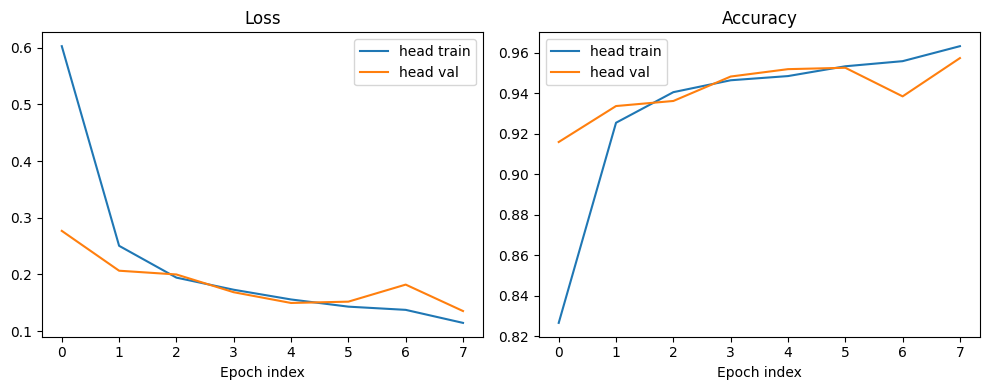

In [ ]:
head_history_df = pd.DataFrame(head_history.history)
head_history_df["stage"] = "head"
history_df = head_history_df.copy()
display(history_df.tail())

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_df.index, history_df["loss"], label="train")
plt.plot(history_df.index, history_df["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("Epoch index")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df.index, history_df["accuracy"], label="train")
plt.plot(history_df.index, history_df["val_accuracy"], label="val")
plt.title("Accuracy")
plt.xlabel("Epoch index")
plt.legend()

plt.tight_layout()
curves_path = FIGURES_DIR / f"{EXPERIMENT_NAME}_training_curves.png"
plt.savefig(curves_path, dpi=150)
plt.show()


## 10. Evaluate on test set


In [ ]:
results = evaluate_model(model, test_ds, class_names)
report = results["classification_report"]
cm = results["confusion_matrix"]

report_df = pd.DataFrame(report).transpose()
display(report_df)

accuracy = float(report["accuracy"])
macro_f1 = float(report["macro avg"]["f1-score"])
weighted_f1 = float(report["weighted avg"]["f1-score"])

print("Test accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Weighted F1:", round(weighted_f1, 4))


,precision,recall,f1-score,support
Apple__Healthy,0.933162,0.994521,0.962865,365.000000
Apple__Rotten,0.970443,0.897494,0.932544,439.000000
Banana__Healthy,0.996656,0.993333,0.994992,300.000000
Banana__Rotten,0.990499,0.995227,0.992857,419.000000
Bellpepper__Healthy,0.916667,0.956522,0.936170,92.000000
Bellpepper__Rotten,0.896104,0.775281,0.831325,89.000000
Carrot__Healthy,0.928571,0.978495,0.952880,93.000000
Carrot__Rotten,0.927711,0.885057,0.905882,87.000000
Cucumber__Healthy,0.947368,0.989011,0.967742,91.000000
Cucumber__Rotten,0.952381,0.898876,0.924855,89.000000


Test accuracy: 0.9524
Macro F1: 0.9252
Weighted F1: 0.9525


## 11. Focus on weak classes from baseline CNN


In [ ]:
weak_classes_from_baseline = [
    "Tomato__Rotten",
    "Bellpepper__Rotten",
    "Potato__Rotten",
    "Pomegranate__Rotten",
    "Carrot__Rotten",
]

available_weak_classes = [name for name in weak_classes_from_baseline if name in report_df.index]
display(report_df.loc[available_weak_classes, ["precision", "recall", "f1-score", "support"]])


,precision,recall,f1-score,support
Tomato__Rotten,0.919540,0.888889,0.903955,90.0
Bellpepper__Rotten,0.896104,0.775281,0.831325,89.0
Potato__Rotten,0.772727,0.781609,0.777143,87.0
Pomegranate__Rotten,0.843750,0.900000,0.870968,30.0
Carrot__Rotten,0.927711,0.885057,0.905882,87.0


## 12. Compare with saved baseline reports


In [ ]:
comparison_paths = {
    "plain_baseline": FIGURES_DIR / "baseline_cnn_classification_report.csv",
    "aug_only": FIGURES_DIR / "baseline_cnn_aug_only_classification_report.csv",
    "aug_oversampled": FIGURES_DIR / "baseline_cnn_aug_oversampled_classification_report.csv",
}

rows = []
for name, path in comparison_paths.items():
    if path.exists():
        prev = pd.read_csv(path, index_col=0)
        rows.append({
            "experiment": name,
            "accuracy": float(prev.loc["accuracy", "precision"]),
            "macro_f1": float(prev.loc["macro avg", "f1-score"]),
            "weighted_f1": float(prev.loc["weighted avg", "f1-score"]),
        })

rows.append({
    "experiment": EXPERIMENT_NAME,
    "accuracy": accuracy,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,
})

comparison_df = pd.DataFrame(rows)
display(comparison_df)


,experiment,accuracy,macro_f1,weighted_f1
0,plain_baseline,0.755464,0.700839,0.744463
1,aug_only,0.750228,0.698354,0.744730
2,aug_oversampled,0.756148,0.721686,0.756913
3,mobilenetv2_aug_oversampled,0.952413,0.925232,0.952505


## 13. Confusion matrix


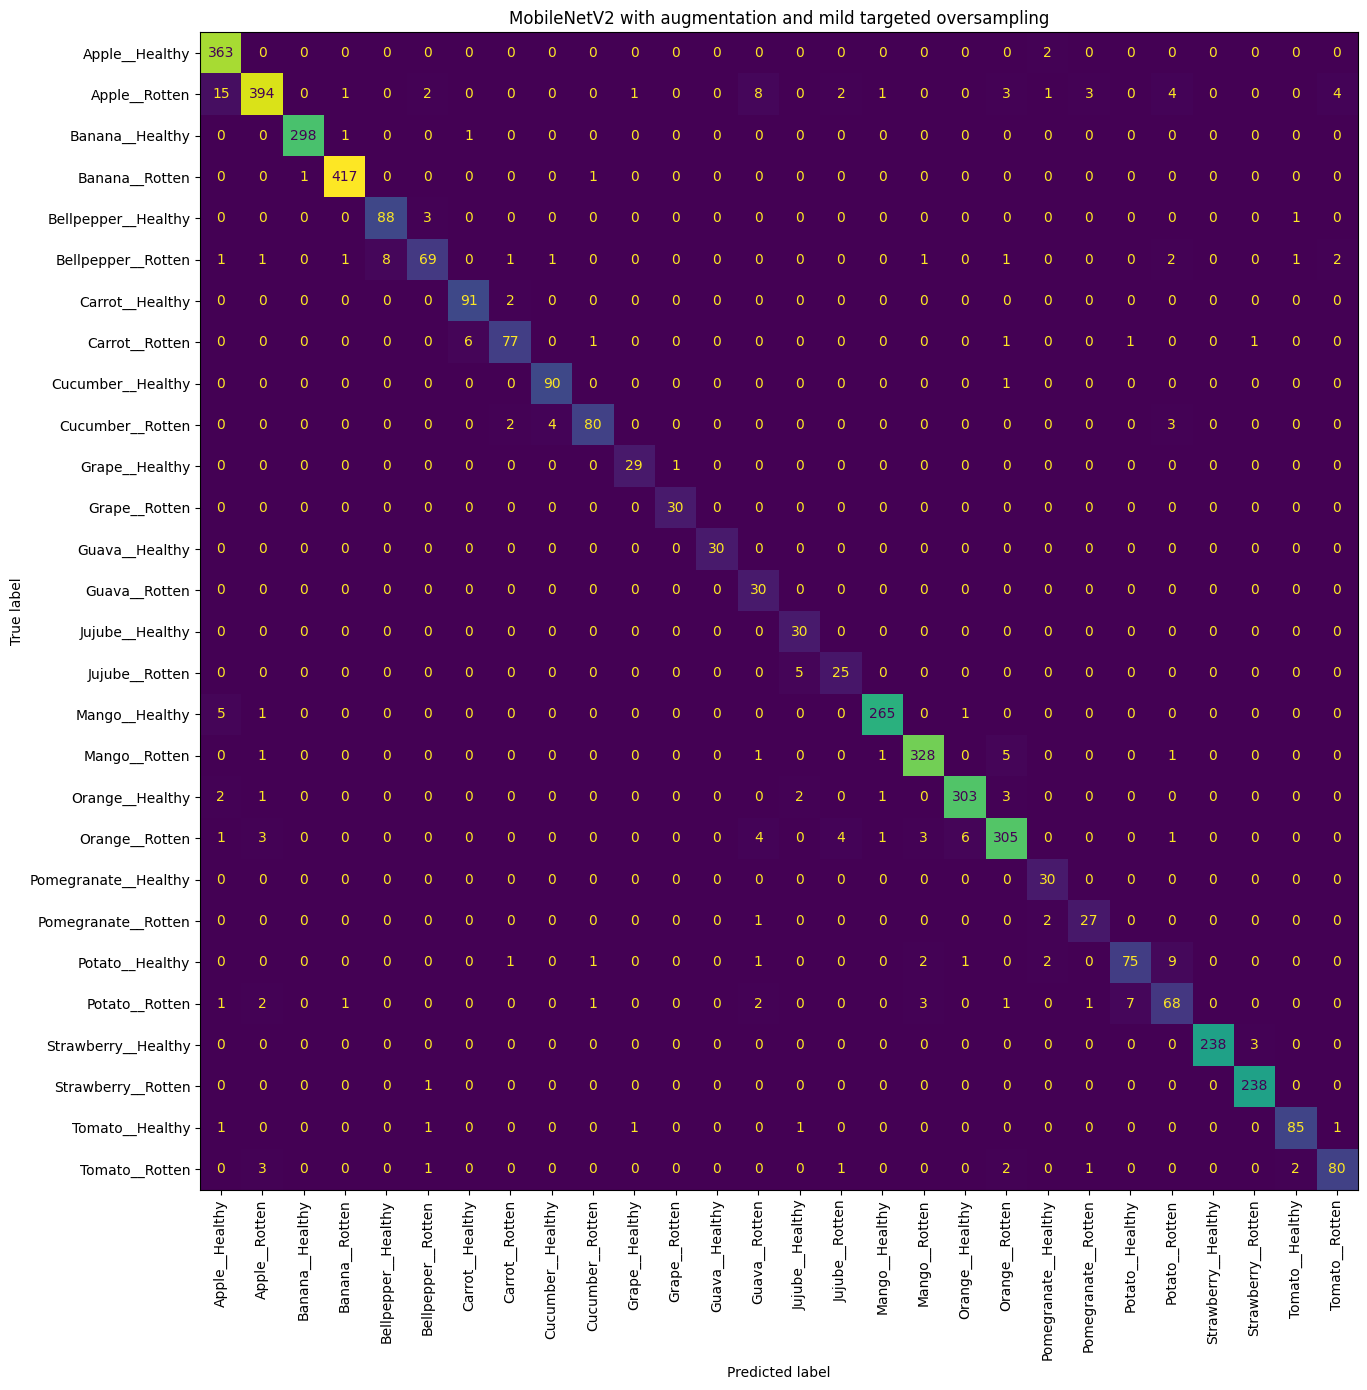

In [ ]:
fig, ax = plt.subplots(figsize=(14, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("MobileNetV2 with augmentation and mild targeted oversampling")
plt.tight_layout()
cm_path = CM_DIR / f"{EXPERIMENT_NAME}_confusion_matrix.png"
plt.savefig(cm_path, dpi=150)
plt.show()


## 14. Save experiment artifacts

This notebook does not overwrite `models/best_model.keras`. The final selected model should only be copied there after all model comparisons are complete.


In [ ]:
model_path = EXPERIMENT_MODELS_DIR / f"{EXPERIMENT_NAME}.keras"
metadata_path = EXPERIMENT_MODELS_DIR / f"{EXPERIMENT_NAME}_metadata.json"
report_path = FIGURES_DIR / f"{EXPERIMENT_NAME}_classification_report.csv"
oversampling_summary_path = EXPERIMENT_MODELS_DIR / f"{EXPERIMENT_NAME}_oversampling_summary.csv"

model.save(model_path)
report_df.to_csv(report_path)
oversampling_summary.to_csv(oversampling_summary_path, index=False)
history_df.to_csv(FIGURES_DIR / f"{EXPERIMENT_NAME}_history.csv", index=False)

metadata = {
    "model_name": EXPERIMENT_NAME,
    "base_model_family": "MobileNetV2",
    "pretrained_weights": PRETRAINED_WEIGHTS,
    "dataset": "muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten",
    "num_classes": NUM_CLASSES,
    "image_size": list(IMAGE_SIZE),
    "head_epochs_requested": HEAD_EPOCHS,
    "head_learning_rate": HEAD_LEARNING_RATE,
    "augmentation": True,
    "class_weighting": None,
    "oversampling": {
        "enabled": True,
        "strategy": "targeted_min_count_with_replacement",
        "target_min_count": TARGET_MIN_COUNT,
        "original_train_rows": int(len(train_df)),
        "oversampled_train_rows": int(len(train_oversampled_df)),
    },
    "trained_at": datetime.now().isoformat(timespec="seconds"),
    "metrics": {
        "test_accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    },
    "artifacts": {
        "model": str(model_path),
        "head_checkpoint": str(head_checkpoint_path),
        "metadata": str(metadata_path),
        "classification_report": str(report_path),
        "oversampling_summary": str(oversampling_summary_path),
        "training_curves": str(curves_path),
        "confusion_matrix": str(cm_path),
    },
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved experiment model:", model_path)
print("Saved metadata:", metadata_path)
print("Saved oversampling summary:", oversampling_summary_path)
print("Did not overwrite models/best_model.keras")


Saved experiment model: D:\UWE\3rd Year\2nd semester\advanced_ai\ai_system\models\experiments\mobilenetv2_aug_oversampled.keras
Saved metadata: D:\UWE\3rd Year\2nd semester\advanced_ai\ai_system\models\experiments\mobilenetv2_aug_oversampled_metadata.json
Saved oversampling summary: D:\UWE\3rd Year\2nd semester\advanced_ai\ai_system\models\experiments\mobilenetv2_aug_oversampled_oversampling_summary.csv
Did not overwrite models/best_model.keras


## 15. Decision rule

MobileNetV2 should beat the best baseline CNN (`03B`) on macro F1, not just accuracy.

If the frozen-base result is already strong, keep it and move to EfficientNetB0. Fine-tuning is handled separately in `04B_mobilenetv2_finetune_wsl.ipynb`.
